In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = r"D:\TrustXAI"

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "Improved_RandomForest_TrustXAI.pkl"
)

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "ready",
    "TrustXAI_Balanced.csv"
)

print("Paths Loaded Successfully.")

Paths Loaded Successfully.


In [3]:
rf_model = joblib.load(MODEL_PATH)

print("Random Forest Loaded Successfully.")

Random Forest Loaded Successfully.


In [4]:
df = pd.read_csv(DATA_PATH)

columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

X = df.drop(columns=columns_to_drop + ["Label"])

print(X.shape)

(49115, 80)


In [5]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,Destination Port,0.065432
69,Init_Win_bytes_backward,0.051824
0,Source Port,0.051358
71,min_seg_size_forward,0.031716
39,Bwd Packets/s,0.028634
68,Init_Win_bytes_forward,0.027449
20,Flow IAT Max,0.024068
17,Flow Packets/s,0.023727
42,Packet Length Mean,0.021312
19,Flow IAT Std,0.020903


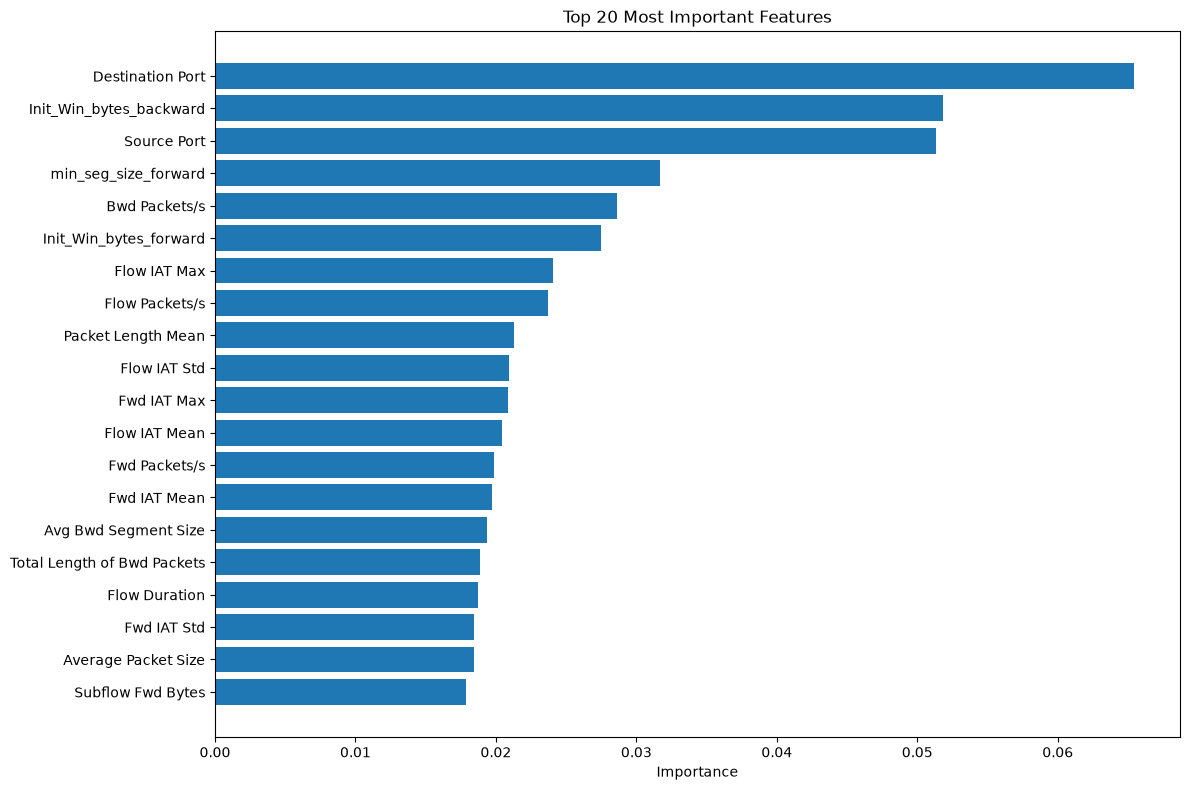

In [6]:
plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Most Important Features")

plt.tight_layout()

plt.show()

In [7]:
RESULT_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)

os.makedirs(RESULT_PATH, exist_ok=True)

feature_importance.to_csv(
    os.path.join(
        RESULT_PATH,
        "Feature_Importance.csv"
    ),
    index=False
)

print("Feature Importance Saved Successfully.")

Feature Importance Saved Successfully.


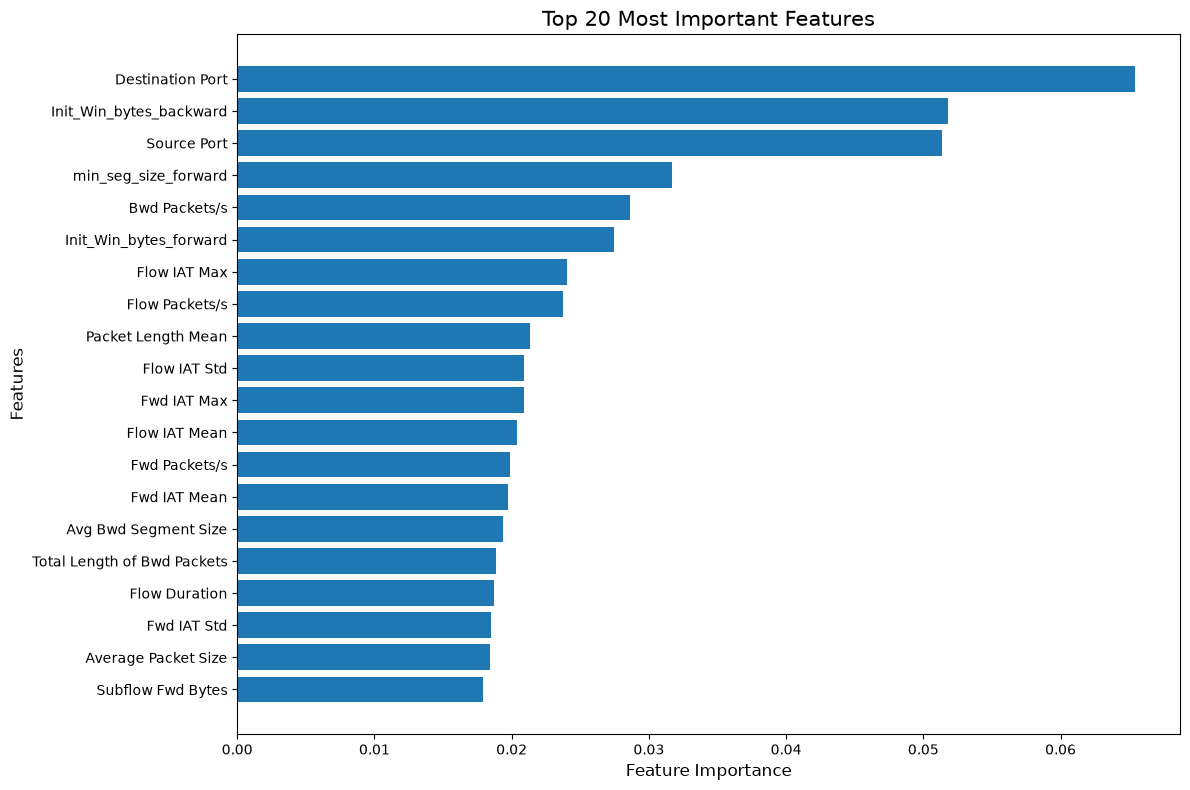

Figure saved successfully.


In [8]:
import os
import matplotlib.pyplot as plt

RESULT_PATH = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULT_PATH, exist_ok=True)

top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.title("Top 20 Most Important Features", fontsize=15)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "Feature_Importance_RF.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")